In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from sklearn.gaussian_process.kernels import RBF
from sklearn.gaussian_process import GaussianProcessRegressor

# Generating Data

In [69]:
x = np.linspace(0, 10, 1000)
y = np.sin(x) * x**2 / 10

In [70]:
np.random.seed(42)

In [71]:
idx = np.random.choice(len(x), 7, replace=False)

x_train, y_train = x[idx].reshape(-1, 1), y[idx].reshape(-1, 1)

In [72]:
kernel = 1 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9, normalize_y=True)

In [73]:
gaussian_process.fit(x_train, y_train)

GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=1),
                         n_restarts_optimizer=9, normalize_y=True)

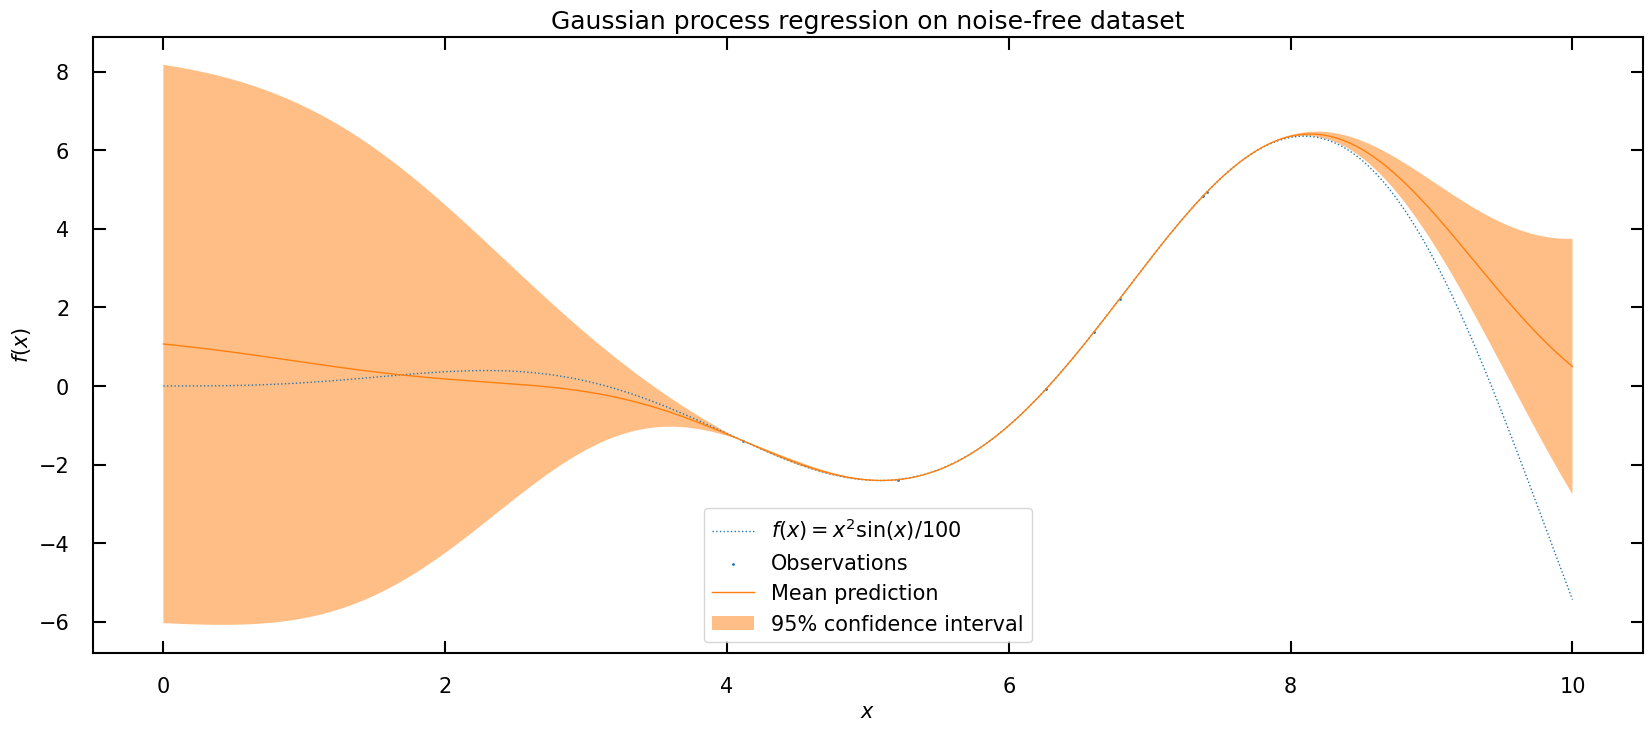

In [95]:
mean_prediction, std_prediction = gaussian_process.predict(x.reshape(-1, 1), return_std=True)

plt.figure(figsize=(20, 8))
plt.plot(x, y, label=r"$f(x) = x^2 \sin(x) / 100$", linestyle="dotted")
plt.scatter(x_train, y_train, label="Observations")
plt.plot(x, mean_prediction, label="Mean prediction")
plt.fill_between(
    x.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.5,
    label=r"95% confidence interval",
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("Gaussian process regression on noise-free dataset")

# Spline Fit

In [85]:
sorting_idx = np.argsort(np.squeeze(x_train))
x_train_sorted = np.squeeze(x_train)[sorting_idx]
y_train_sorted = np.squeeze(y_train)[sorting_idx]

In [86]:
spline = CubicSpline(x_train_sorted, y_train_sorted)

In [88]:
y_pred_spline = spline(x)

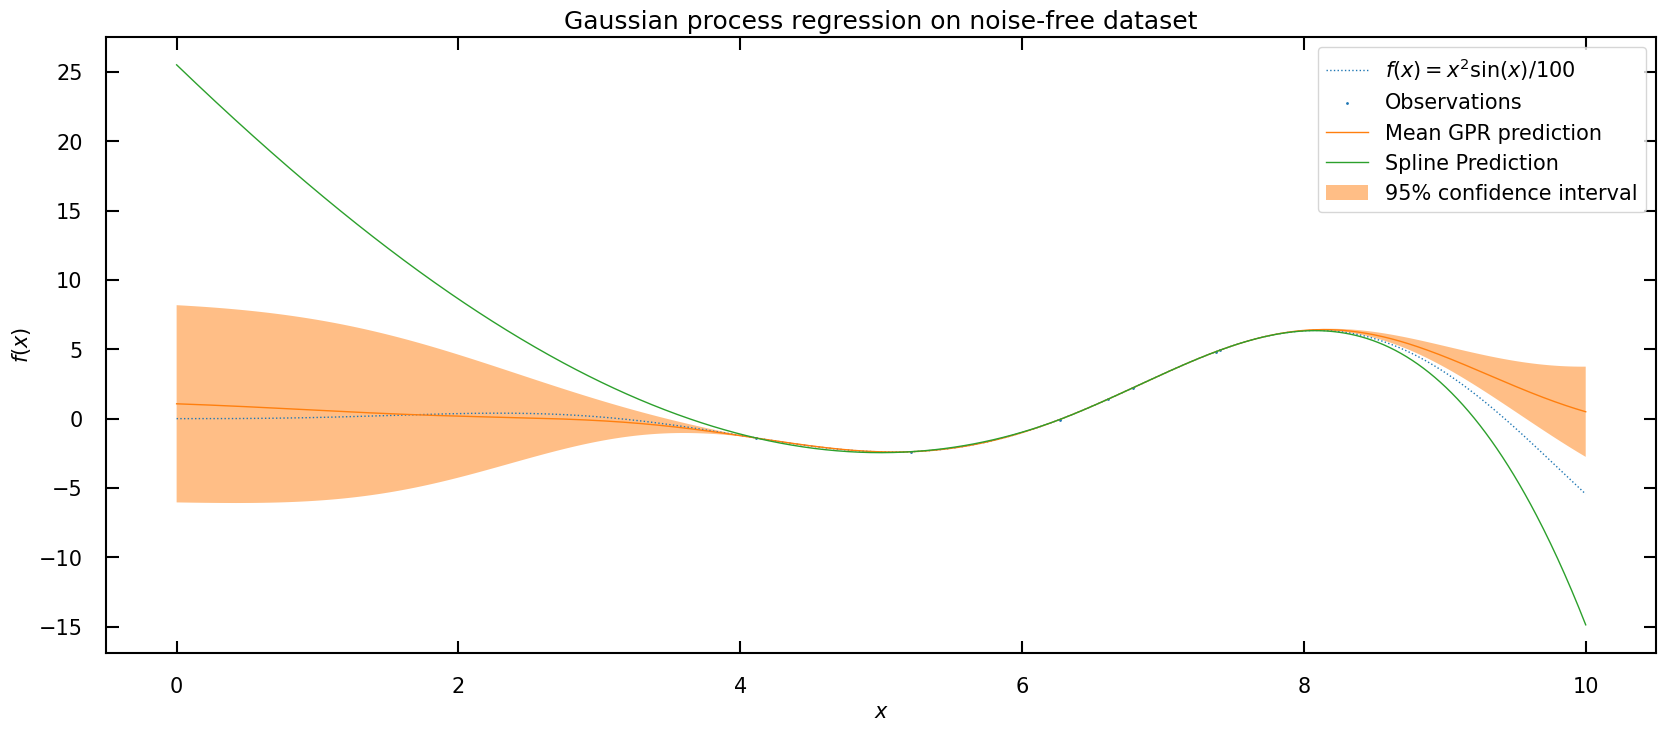

In [94]:
plt.figure(figsize=(20, 8))
plt.plot(x, y, label=r"$f(x) = x^2 \sin(x) / 100$", linestyle="dotted")
plt.scatter(x_train, y_train, label="Observations")
plt.plot(x, mean_prediction, label="Mean GPR prediction")
plt.plot(x, y_pred_spline, label='Spline Prediction')
plt.fill_between(
    x.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.5,
    label=r"95% confidence interval",
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("Gaussian process regression on noise-free dataset")